# Proyecto 1: ¿Compra el dinero los goles?

**Economía, población y el desempeño de las selecciones nacionales de fútbol (1960–2025)**

Ciencia de Datos · Sección A · Segundo semestre 2026

**Autor:** Milton Beltrán
**Dataset:** International football results 1872–2026 (martj42) + World Development Indicators (Banco Mundial) + Population estimates (ONS, Reino Unido)


### Rúbrica resumida

| Criterio | Pts | Qué buscamos |
|---|---|---|
| Pregunta y datos | 2 | Pregunta clara, provenance del dataset |
| EDA | 3 | Hallazgos, no galería de gráficas |
| Features | 2 | Cada decisión justificada, sin leakage |
| Baseline | 2 | Validación correcta, métrica adecuada |
| Límites | 1 | Qué no puede concluirse con estos datos |


## 1. Pregunta y contexto

El fútbol tiene fama de ser el deporte del pueblo, el que solo necesita una pelota y un pedazo de tierra. A diferencia de otros deportes como la natación o la equitación, donde el desarrollo del país limita las instalaciones disponibles, el fútbol permitiría que naciones pobres compitan de igual a igual con naciones ricas. Uruguay tiene 3.4 millones de habitantes y dos Copas del Mundo. Brasil ganó cinco siendo, durante la mayor parte de ese tiempo, un país de ingreso medio-bajo.

¿Es eso cierto, o es folclore que repetimos porque nos gusta cómo suena? Este proyecto lo pone a prueba con los 49,547 partidos internacionales registrados desde 1872 y los indicadores económicos del Banco Mundial.

**A quién le serviría la respuesta.** A quien decide dónde poner el dinero público del deporte. Si el desempeño futbolístico de un país estuviera determinado por su PIB, invertir en fútbol de alto rendimiento sería tirar plata, ya que ningún programa de desarrollo va a cambiar el PIB per cápita del país. Si no lo está, si hay países que rinden muy por encima de lo que su economía predice, entonces esa brecha es justamente el espacio donde la gestión, la formación de canteras y la organización de la liga sí hacen diferencia. 

**Y la pregunta que motivó el proyecto.** Guatemala nunca ha clasificado a un Mundial. Costa Rica, con una población parecida y una economía comparable, ha ido a seis y llegó a cuartos de final en 2014. ¿Es Guatemala un país que rinde por debajo de lo que le tocaría, o estamos limitados y destinados por nuestro entorno? No se puede responder mirando solo a Guatemala: hace falta construir una expectativa a partir de los 200 países del mundo y después ver dónde cae Guatemala respecto a esa expectativa.

---

**Pregunta:** ¿Se explica el desempeño de una selección nacional a partir del PIB per cápita y la población de su país? Y dado ese modelo, ¿Guatemala rinde por encima o por debajo de lo esperado?

**Tipo de problema:** regresión

**Variable objetivo:** se evalúan dos, con una principal y una secundaria.

| | Variable | Rol | Por qué |
|---|---|---|---|
| **Principal** | `winrate` — proporción de partidos ganados en el año | Responde la pregunta | Es lo que de verdad importa deportivamente (clasificar, avanzar de ronda) y es robusta: una goleada de 8-0 pesa lo mismo que un 1-0, que es como debe ser |
| Secundaria | `gd` — diferencia de goles promedio en el año | Contraste | Tiene más información por partido (distingue perder 0-1 de perder 0-5), pero es sensible a goleadas y a la calidad del rival |

Se reportan las dos. Si ambas apuntan en la misma dirección, la conclusión es más sólida que con cualquiera de las dos sola. `winrate` manda en caso de desacuerdo, porque un empate y una derrota no son lo mismo que un gol más o menos.

**Unidad de observación:** un país en un año (por ejemplo, "Guatemala, 2019"), agregando todos los partidos internacionales que jugó ese año.


## 2. Los datos

Tres fuentes, todas públicas y de acceso abierto. La ficha completa está en `data/procedencia.json`; aquí va el resumen.

| | Partidos | Economía | Población del Reino Unido |
|---|---|---|---|
| **Fuente** | [martj42/international_results](https://github.com/martj42/international_results) | [API del Banco Mundial](https://data.worldbank.org) | [ONS](https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates) |
| **Licencia** | **CC0-1.0** (dominio público) | **CC BY 4.0** | **Open Government Licence v3.0** |
| **Fecha de descarga** | 2026-09-14 | 2026-09-14 | 2026-09-14 |
| **Acceso** | CSV directo | API pública, sin llave | API pública, sin llave |
| **Filas** | 49,547 partidos | 17,490 entidad-año | 54 años × 5 series |
| **Rango** | 1872-11-30 a 2026-08-26 | 1960–2025 | 1971–2024 |
| **Unidad** | un partido | una entidad-año | un país-año |

**Diccionario de variables (las que se usan)**

*De `results.csv`:* `date` (fecha), `home_team` / `away_team` (selecciones), `home_score` / `away_score` (goles en tiempo reglamentario y extra, **sin** penales), `tournament` (competición, 202 distintas), `neutral` (si se jugó en cancha neutral).

*Del Banco Mundial:* `NY.GDP.PCAP.KD` (PIB per cápita en **dólares constantes de 2015**) y `SP.POP.TOTL` (población total).

*Del ONS:* estimaciones de población a mitad de año para Inglaterra, Escocia, Gales e Irlanda del Norte por separado.

---

### Tres decisiones de procedencia que hay que declarar de entrada

**① Se usa el PIB en dólares constantes, no corrientes.** El indicador obvio del Banco Mundial es `NY.GDP.PCAP.CD`, en dólares corrientes. Con él, el PIB per cápita de Guatemala pasa de \$353 en 1970 a \$4,477 en 2020: un crecimiento de 12.7×. Pero casi todo eso es inflación del dólar, no riqueza real. En dólares constantes de 2015 (`NY.GDP.PCAP.KD`) va de \$2,425 a \$4,006, un crecimiento real de 1.65×. Para un panel que cubre 65 años, usar dólares corrientes habría metido la inflación estadounidense como si fuera desarrollo económico guatemalteco.

**② El Banco Mundial devuelve 265 entidades, pero solo 217 son países.** Las otras 78 son agregados: `World`, `Euro area`, `High income`, `Arab World`, `IDA only`. Se filtran usando `wb_countries.json`, donde los agregados tienen `region == "Aggregates"`. Sin ese filtro, el análisis se contamina con filas que no son naciones.

**③ Por qué hay una tercera fuente solo para el Reino Unido.** Inglaterra, Escocia, Gales e Irlanda del Norte juegan por separado en fútbol —son los fundadores del deporte y aportan 265 país-años— pero el Banco Mundial solo conoce *"United Kingdom"*. Excluirlos deformaría un estudio sobre fútbol internacional. La solución es asimétrica a propósito: **la población se toma real de cada nación** (varía 30× entre Inglaterra e Irlanda del Norte, y es el predictor más fuerte del modelo), mientras que **el PIB per cápita se aproxima con el del Reino Unido completo** (varía poco entre ellas) y se marca con la bandera `gdppc_aproximado` para poder excluirlas y verificar que las conclusiones no dependen de esa aproximación.

### Una fuente que se evaluó y se descartó

Se evaluó la [Maddison Project Database 2023](https://www.rug.nl/ggdc/historicaldevelopment/maddison/releases/maddison-project-database-2023) para recuperar el PIB de los estados desaparecidos. Se descartó por cuatro razones medidas, no supuestas: (a) solo cubre Checoslovaquia y Yugoslavia, no Alemania Democrática ni Vietnam del Sur, lo que recupera 66 país-años de 7,661 (0.9%); (b) sus unidades son dólares internacionales PPP de 2011 y el desfase contra el Banco Mundial no es constante —pasa de 9.24× en 1970 a 1.80× en 2020—, así que no se corrige reescalando; (c) cubre 169 países contra 217, y cambiar de fuente costaría 40 selecciones, más de las que recupera; (d) requiere `openpyxl`, que no está en el entorno del curso.

La evaluación no se desperdició fue que al comparar ambas fuentes que se detectó el problema de los dólares corrientes descrito en el punto 1. Los estados desaparecidos se tratan como faltante MNAR y se documentan en la sección 4.


In [119]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

ANCHO = 68

# encabezado de bloque, para que las salidas no se amontonen
def titulo(texto):
    print()
    print(texto)
    print("-" * ANCHO)

RANDOM_STATE = 42
RAW = Path("data/raw")

pd.set_option("display.width", 120)


In [120]:
# results.csv tal como viene: una fila por partido
def cargar_partidos():
    df = pd.read_csv(RAW / "results.csv", parse_dates=["date"])
    df["year"] = df["date"].dt.year
    return df


# un indicador del Banco Mundial, ya sin los 78 agregados
def cargar_indicador_bm(indicador, nombre):
    meta = json.loads((RAW / "wb_countries.json").read_text())[1]
    paises_reales = {c["name"] for c in meta if c["region"]["value"] != "Aggregates"}

    registros = json.loads((RAW / f"wb_{indicador}.json").read_text())[1]
    df = pd.DataFrame([
        {"wb_country": r["country"]["value"], "year": int(r["date"]), nombre: r["value"]}
        for r in registros
    ])
    return df[df["wb_country"].isin(paises_reales)].reset_index(drop=True)


# region del Banco Mundial por pais, para usarla como categorica
def cargar_regiones_bm():
    meta = json.loads((RAW / "wb_countries.json").read_text())[1]
    return {c["name"]: c["region"]["value"] for c in meta
            if c["region"]["value"] != "Aggregates"}


# poblacion de las cuatro naciones britanicas, que el Banco Mundial no separa
def cargar_poblacion_ons():
    series = {"enpop": "England", "scpop": "Scotland",
              "wapop": "Wales", "nipop": "Northern Ireland"}
    filas = []
    for archivo, pais in series.items():
        datos = json.loads((RAW / f"ons_{archivo}.json").read_text())
        for obs in datos["years"]:
            filas.append({"team": pais, "year": int(obs["year"]),
                          "pop_ons": float(obs["value"])})
    return pd.DataFrame(filas)


partidos = cargar_partidos()
gdppc = cargar_indicador_bm("NY.GDP.PCAP.KD", "gdppc")
poblacion = cargar_indicador_bm("SP.POP.TOTL", "pop")
regiones = cargar_regiones_bm()
pop_uk = cargar_poblacion_ons()

titulo("FUENTES CARGADAS")
print(f"  {'partidos':<12} {partidos.shape[0]:>7,} filas x {partidos.shape[1]} columnas")
print(f"  {'gdppc':<12} {gdppc.shape[0]:>7,} filas x {gdppc.shape[1]} columnas   "
      f"({gdppc['wb_country'].nunique()} países)")
print(f"  {'población':<12} {poblacion.shape[0]:>7,} filas x {poblacion.shape[1]} columnas")
print(f"  {'pop_uk':<12} {pop_uk.shape[0]:>7,} filas x {pop_uk.shape[1]} columnas   "
      f"({', '.join(sorted(pop_uk['team'].unique()))})")



FUENTES CARGADAS
--------------------------------------------------------------------
  partidos      49,547 filas x 10 columnas
  gdppc         14,322 filas x 3 columnas   (217 países)
  población     14,322 filas x 3 columnas
  pop_uk           216 filas x 3 columnas   (England, Northern Ireland, Scotland, Wales)


## 3. Primer barrido

Forma, tipos y una mirada rápida a las categóricas de la fuente principal.


In [121]:
titulo("FORMA")
print(f"  {partidos.shape[0]:,} partidos y {partidos.shape[1]} columnas")

titulo("TIPOS")
print(partidos.dtypes.to_string())

titulo("FALTANTES POR COLUMNA")
print(partidos.isna().sum().to_string())

partidos.head()



FORMA
--------------------------------------------------------------------
  49,547 partidos y 10 columnas

TIPOS
--------------------------------------------------------------------
date          datetime64[us]
home_team                str
away_team                str
home_score             int64
away_score             int64
tournament               str
city                     str
country                  str
neutral                 bool
year                   int32

FALTANTES POR COLUMNA
--------------------------------------------------------------------
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
year          0


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1875
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1876


In [122]:
titulo("NUMÉRICAS")
print(partidos[["home_score", "away_score"]].describe().round(2).to_string())

titulo("CATEGÓRICAS")
print(f"  Equipos distintos: {len(set(partidos['home_team']) | set(partidos['away_team']))}")
print(f"  Torneos distintos: {partidos['tournament'].nunique()}")

titulo("TOP 10 TORNEOS")
for nombre, n in partidos["tournament"].value_counts().head(10).items():
    print(f"  {nombre:<40} {n:>6,}  ({n / len(partidos):>5.1%})")

titulo("CANCHA NEUTRAL")
for valor, pct in partidos["neutral"].value_counts(normalize=True).items():
    print(f"  {'neutral' if valor else 'con local':<40} {pct:>6.1%}")



NUMÉRICAS
--------------------------------------------------------------------
       home_score  away_score
count    49547.00    49547.00
mean         1.76        1.18
std          1.77        1.40
min          0.00        0.00
25%          1.00        0.00
50%          1.00        1.00
75%          2.00        2.00
max         31.00       21.00

CATEGÓRICAS
--------------------------------------------------------------------
  Equipos distintos: 337
  Torneos distintos: 202

TOP 10 TORNEOS
--------------------------------------------------------------------
  Friendly                                 18,385  (37.1%)
  FIFA World Cup qualification              8,771  (17.7%)
  UEFA Euro qualification                   2,824  ( 5.7%)
  African Cup of Nations qualification      2,327  ( 4.7%)
  FIFA World Cup                            1,068  ( 2.2%)
  Copa América                                869  ( 1.8%)
  African Cup of Nations                      845  ( 1.7%)
  AFC Asian Cup qual

In [123]:
# cuantos partidos tiene Guatemala y como se reparten en el tiempo
gt = partidos[(partidos["home_team"] == "Guatemala") | (partidos["away_team"] == "Guatemala")]

titulo("GUATEMALA EN EL DATASET")
print(f"  {len(gt)} partidos, de {gt['date'].min().date()} a {gt['date'].max().date()}")
print()
for decada, n in gt.groupby(gt["date"].dt.year // 10 * 10).size().items():
    print(f"  {decada}s  {'#' * n}  {n}")



GUATEMALA EN EL DATASET
--------------------------------------------------------------------
  554 partidos, de 1921-09-18 a 2026-06-07

  1920s  #######  7
  1930s  #######  7
  1940s  #########################  25
  1950s  ################  16
  1960s  ##########################################  42
  1970s  #############################  29
  1980s  ################################################################  64
  1990s  ######################################################################  70
  2000s  #####################################################################################################################################  133
  2010s  ###################################################################################  83
  2020s  ##############################################################################  78


**Observaciones del primer barrido:**

1. **El dataset de partidos no tiene un solo valor faltante** en sus 9 columnas y 49,547 filas. Esto es inusual y cambia el enfoque de la sección 4: los faltantes de este proyecto no vienen heredados de la fuente, sino que los vamos a crear nosotros al unir el fútbol con la economía.

2. **El 37% de los partidos son amistosos.** No pesan lo mismo que una eliminatoria: se juegan con suplentes, sin presión y a veces contra rivales elegidos por conveniencia comercial. Hay que medir qué proporción de amistosos juega cada país-año y controlarla.

3. **Hay 337 equipos, pero no todos son países.** Aparecen `Ynys Môn` (la isla galesa de Anglesey), `Shetland`, `Orkney`, `Isle of Wight`, `Padania`, `Sápmi`, `Frøya` y `Saare County`: son selecciones de los Island Games y equipos no-FIFA. Hay que filtrarlos explícitamente.


## 4. Calidad de datos

Tres cosas en orden: construir la tabla país-año, medir qué se pierde al unirla con la economía y argumentar el mecanismo de esos faltantes.


In [124]:
# duplicados
dups = partidos.duplicated().sum()
llave = ["date", "home_team", "away_team"]
dups_llave = partidos.duplicated(subset=llave).sum()

titulo("DUPLICADOS")
print(f"  {'filas idénticas':<34} {dups:>6,}")
print(f"  {'misma fecha y mismos dos equipos':<34} {dups_llave:>6,}")

if dups_llave:
    print()
    print("  El caso marcado por la llave, en detalle:")
    repetidos = partidos.duplicated(subset=llave, keep=False)
    print(partidos[repetidos][llave + ["home_score", "away_score", "tournament"]].to_string(index=False))

# outliers por IQR sobre la diferencia de goles de cada partido
partidos["dif"] = partidos["home_score"] - partidos["away_score"]
q1, q3 = partidos["dif"].quantile([0.25, 0.75])
iqr = q3 - q1
bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr

fuera = partidos[(partidos["dif"] < bajo) | (partidos["dif"] > alto)]

titulo("OUTLIERS POR IQR EN LA DIFERENCIA DE GOLES")
print(f"  {'Q1 / Q3 / IQR':<30} {q1:.0f} / {q3:.0f} / {iqr:.0f}")
print(f"  {'rango aceptado':<30} [{bajo:.1f}, {alto:.1f}]")
print(f"  {'partidos fuera del rango':<30} {len(fuera):,}  ({len(fuera) / len(partidos):.1%})")
print(f"  {'goleadas del local':<30} {(fuera['dif'] > 0).sum():,}")
print(f"  {'goleadas del visitante':<30} {(fuera['dif'] < 0).sum():,}")

titulo("LAS 5 MAYORES GOLEADAS DE LA HISTORIA")
for _, f in partidos.nlargest(5, "dif").iterrows():
    print(f"  {f['date'].date()}  {f['home_team']:>16} {f['home_score']:>3}-{f['away_score']:<3} "
          f"{f['away_team']:<16} {f['tournament']}")



DUPLICADOS
--------------------------------------------------------------------
  filas idénticas                         0
  misma fecha y mismos dos equipos        1

  El caso marcado por la llave, en detalle:
      date home_team     away_team  home_score  away_score tournament
1974-02-17    Tahiti New Caledonia           2           1   Friendly
1974-02-17    Tahiti New Caledonia           1           2   Friendly

OUTLIERS POR IQR EN LA DIFERENCIA DE GOLES
--------------------------------------------------------------------
  Q1 / Q3 / IQR                  -1 / 2 / 3
  rango aceptado                 [-5.5, 6.5]
  partidos fuera del rango       1,327  (2.7%)
  goleadas del local             823
  goleadas del visitante         504

LAS 5 MAYORES GOLEADAS DE LA HISTORIA
--------------------------------------------------------------------
  2001-04-11         Australia  31-0   American Samoa   FIFA World Cup qualification
  1971-09-13            Tahiti  30-0   Cook Islands     Sout

**Duplicados y outliers: qué se hizo y por qué.**

**Duplicados: ninguno real.** No hay ni una fila idéntica en las 49,547. La llave más laxa —misma fecha y mismos dos equipos— marca **un solo caso**, y al mirarlo resulta que no es un duplicado: Tahití y Nueva Caledonia jugaron **dos amistosos el mismo día**, 17 de febrero de 1974 en Papeete, con resultados distintos (2-1 y 1-2). Son dos partidos reales, no un registro repetido. Borrar por llave habría eliminado un resultado legítimo. No se eliminó nada.

**Outliers: existen, son muchos, y tampoco se tocan.** El criterio del IQR sobre la diferencia de goles da Q1 = −1 y Q3 = 2, lo que deja como rango aceptado [−5.5, 6.5]: queda marcado como atípico todo partido ganado o perdido por más de 6 goles. Son **1,327 partidos, el 2.7% del total**.

La pregunta de la plantilla es si son **error de captura o señal real**, y aquí la respuesta es inequívoca: son reales y además célebres. El primero de la lista es **Australia 31-0 Samoa Americana (2001)**, el récord histórico del fútbol internacional, jugado en una eliminatoria mundialista de la OFC. Le siguen Tahití 30-0 Islas Cook y Fiyi 24-0 Kiribati. No son errores de digitación: son partidos documentados entre selecciones con una diferencia de nivel enorme.

Por eso **no se eliminan**. Borrarlos sería borrar precisamente el fenómeno que el proyecto quiere medir: la disparidad entre selecciones. Un filtro por IQR aquí no limpiaría datos sucios, mutilaría la variable objetivo.

Sí dejan tres cosas anotadas que se arrastran al resto del análisis:

1. **Explican el sesgo de `gd`.** Estas goleadas son la razón de que la diferencia de goles promedio anual llegue a −13.0 por el extremo malo y solo a +5.0 por el bueno. Es el argumento que sostiene la elección de `winrate` como target principal en la sección 5.
2. **Se concentran en la OFC.** Tahití, Fiyi y Kiribati aparecen en el top 5, y son las mismas selecciones del problema de la fuerza del rival. Los outliers no están repartidos al azar: se acumulan donde el desnivel entre rivales es mayor, que es justo lo que `fuerza_rival` intenta corregir.
3. **Hasta los outliers tienen ventaja de local.** De los 1,327 partidos atípicos, **823 son goleadas del local contra 504 del visitante**. La ventaja de jugar en casa no solo cambia quién gana: cambia por cuánto. Es evidencia independiente de que `pct_local` merece estar entre los controles del modelo.


In [125]:
# de una fila por partido a dos: una por cada equipo que jugo.
# asi goles a favor y en contra quedan siempre relativos al equipo de la fila.
def a_perspectiva_equipo(df):
    local = df.assign(team=df["home_team"], opponent=df["away_team"],
                      gf=df["home_score"], ga=df["away_score"],
                      is_home=~df["neutral"])
    visita = df.assign(team=df["away_team"], opponent=df["home_team"],
                       gf=df["away_score"], ga=df["home_score"],
                       is_home=False)

    cols = ["date", "year", "team", "opponent", "gf", "ga", "tournament", "is_home"]
    largo = pd.concat([local[cols], visita[cols]], ignore_index=True)

    largo["gd"] = largo["gf"] - largo["ga"]
    largo["gano"] = largo["gd"] > 0
    largo["oficial"] = largo["tournament"] != "Friendly"
    return largo


largo = a_perspectiva_equipo(partidos)

titulo("DE PARTIDO A PERSPECTIVA DE EQUIPO")
print(f"  {len(partidos):,} partidos  ->  {len(largo):,} filas equipo-partido")

# Verificacion: cada partido tiene que aportar exactamente dos filas
assert len(largo) == 2 * len(partidos)

largo.head(3)



DE PARTIDO A PERSPECTIVA DE EQUIPO
--------------------------------------------------------------------
  49,547 partidos  ->  99,094 filas equipo-partido


,date,year,team,opponent,gf,ga,tournament,is_home,gd,gano,oficial
0,1872-11-30,1872,Scotland,England,0,0,Friendly,True,0,False,False
1,1873-03-08,1873,England,Scotland,4,2,Friendly,True,2,True,False
2,1874-03-07,1874,Scotland,England,2,1,Friendly,True,1,True,False


In [126]:
MIN_PARTIDOS = 4   # ver justificacion abajo

# una fila por (equipo, año) con los dos targets y los controles
def a_pais_anio(largo, min_partidos=MIN_PARTIDOS):
    cy = largo.groupby(["team", "year"]).agg(
        n_partidos=("gd", "size"),
        winrate=("gano", "mean"),      # TARGET PRINCIPAL
        gd=("gd", "mean"),             # target secundario
        pct_local=("is_home", "mean"),
        pct_oficial=("oficial", "mean"),
    ).reset_index()
    return cy[cy["n_partidos"] >= min_partidos].reset_index(drop=True)


pais_anio = a_pais_anio(largo)

titulo(f"TABLA PAÍS-AÑO (mínimo {MIN_PARTIDOS} partidos al año)")
print(f"  {'filas':<22} {len(pais_anio):>7,}")
print(f"  {'equipos':<22} {pais_anio['team'].nunique():>7}")
print(f"  {'rango':<22} {pais_anio['year'].min()}–{pais_anio['year'].max()}")

pais_anio.head()



TABLA PAÍS-AÑO (mínimo 4 partidos al año)
--------------------------------------------------------------------
  filas                   10,176
  equipos                    293
  rango                  1888–2026


,team,year,n_partidos,winrate,gd,pct_local,pct_oficial
0,Abkhazia,2014,5,0.200000,0.000000,0.000000,1.000000
1,Abkhazia,2016,6,0.666667,2.333333,1.000000,0.833333
2,Abkhazia,2017,6,0.166667,-0.333333,0.166667,0.833333
3,Abkhazia,2018,6,0.666667,1.833333,0.000000,1.000000
4,Abkhazia,2019,5,0.400000,0.600000,0.000000,1.000000


**Por qué el umbral de 4 partidos.** Con uno o dos partidos al año, `winrate` solo puede valer 0, 0.5 o 1, y `gd` depende de un solo resultado raro. El umbral descarta esas filas de puro ruido. Se eligió 4 como punto de corte razonable.


In [127]:
# las dos fuentes escriben distinto el mismo pais
NOMBRES_BM = {
    "South Korea": "Korea, Rep.",          "North Korea": "Korea, Dem. People's Rep.",
    "Russia": "Russian Federation",        "Turkey": "Turkiye",
    "Ivory Coast": "Cote d'Ivoire",        "DR Congo": "Congo, Dem. Rep.",
    "Congo": "Congo, Rep.",                "Egypt": "Egypt, Arab Rep.",
    "Iran": "Iran, Islamic Rep.",          "Venezuela": "Venezuela, RB",
    "Syria": "Syrian Arab Republic",       "Yemen": "Yemen, Rep.",
    "Laos": "Lao PDR",                     "Cape Verde": "Cabo Verde",
    "Vietnam": "Viet Nam",                 "Kyrgyzstan": "Kyrgyz Republic",
    "Slovakia": "Slovak Republic",         "Czech Republic": "Czechia",
    "Gambia": "Gambia, The",               "Bahamas": "Bahamas, The",
    "Hong Kong": "Hong Kong SAR, China",   "Macau": "Macao SAR, China",
    "Brunei": "Brunei Darussalam",         "Saint Kitts and Nevis": "St. Kitts and Nevis",
    "Saint Lucia": "St. Lucia",            "Republic of Ireland": "Ireland",
    "Saint Vincent and the Grenadines": "St. Vincent and the Grenadines",
    "São Tomé and Príncipe": "Sao Tome and Principe",
    "Palestine": "West Bank and Gaza",     "Curaçao": "Curacao",
    "United States Virgin Islands": "Virgin Islands (U.S.)",
    "Saint Martin": "St. Martin (French part)",
    "Micronesia": "Micronesia, Fed. Sts.",
}

pais_anio["wb_country"] = pais_anio["team"].map(NOMBRES_BM).fillna(pais_anio["team"])

# cuanto rescata el diccionario
nombres_bm = set(gdppc["wb_country"].unique())
en_rango = pais_anio[pais_anio["year"] >= 1960]

sin_dicc = en_rango["team"].isin(nombres_bm).mean()
con_dicc = en_rango["wb_country"].isin(nombres_bm).mean()

titulo("MATCH POR NOMBRE CONTRA EL BANCO MUNDIAL (1960+)")
print(f"  {'sin diccionario':<22} {sin_dicc:>7.1%}")
print(f"  {'con diccionario':<22} {con_dicc:>7.1%}")
print(f"  {'rescatado':<22} {con_dicc - sin_dicc:>+7.1%}  ({len(NOMBRES_BM)} nombres traducidos)")



MATCH POR NOMBRE CONTRA EL BANCO MUNDIAL (1960+)
--------------------------------------------------------------------
  sin diccionario          77.4%
  con diccionario          90.4%
  rescatado               +12.9%  (33 nombres traducidos)


In [128]:
datos = (pais_anio
         .merge(gdppc, on=["wb_country", "year"], how="left")
         .merge(poblacion, on=["wb_country", "year"], how="left"))

# Reino Unido: poblacion real de cada nacion (ONS), PIB aproximado con el del RU
uk_gdppc = (gdppc[gdppc["wb_country"] == "United Kingdom"][["year", "gdppc"]]
            .rename(columns={"gdppc": "gdppc_uk"}))

datos = datos.merge(pop_uk, on=["team", "year"], how="left").merge(uk_gdppc, on="year", how="left")

BRITANICAS = ["England", "Scotland", "Wales", "Northern Ireland"]
es_britanica = datos["team"].isin(BRITANICAS)

datos["gdppc_aproximado"] = es_britanica & datos["gdppc"].isna() & datos["gdppc_uk"].notna()
datos.loc[es_britanica, "pop"] = datos.loc[es_britanica, "pop_ons"]
datos.loc[datos["gdppc_aproximado"], "gdppc"] = datos.loc[datos["gdppc_aproximado"], "gdppc_uk"]

datos = datos.drop(columns=["pop_ons", "gdppc_uk"])

titulo("MERGE CON LA ECONOMÍA")
print(f"  {'filas tras el merge':<32} {len(datos):>6,}")
print(f"  {'con PIB':<32} {datos['gdppc'].notna().sum():>6,}")
print(f"  {'recuperadas del Reino Unido':<32} {datos['gdppc_aproximado'].sum():>6,} años")



MERGE CON LA ECONOMÍA
--------------------------------------------------------------------
  filas tras el merge              10,176
  con PIB                           7,837
  recuperadas del Reino Unido         261 años


In [129]:
# que se pierde y por que: clasificar los fallos en familias
EXTINTOS = ["Czechoslovakia", "Yugoslavia", "German DR", "Vietnam Republic"]
NO_PAISES = ["Ynys Môn", "Shetland", "Orkney", "Isle of Wight", "Padania", "Sápmi",
             "Frøya", "Saare County", "Western Isles", "Gotland", "Menorca",
             "Provence", "Alderney", "Åland Islands", "Jersey", "Guernsey"]

perdidas = datos[datos["gdppc"].isna() & (datos["year"] >= 1960)].copy()

def familia(equipo):
    if equipo in BRITANICAS:
        return "1. Naciones británicas (sin dato ONS)"
    if equipo in EXTINTOS:
        return "2. Estados desaparecidos"
    if equipo in NO_PAISES:
        return "3. Selecciones que no son países"
    return "4. Territorios y otros sin PIB reportado"

perdidas["familia"] = perdidas["team"].map(familia)

titulo("PAÍS-AÑOS SIN PIB, POR FAMILIA (1960+)")
for nombre, n in perdidas["familia"].value_counts().sort_index().items():
    print(f"  {nombre:<42} {n:>5,}")
print(f"  {'TOTAL':<42} {len(perdidas):>5,}")

titulo("ESTADOS DESAPARECIDOS, EN DETALLE")
for equipo, n in perdidas[perdidas["familia"].str.startswith("2.")].groupby("team").size().items():
    print(f"  {equipo:<42} {n:>5} años")



PAÍS-AÑOS SIN PIB, POR FAMILIA (1960+)
--------------------------------------------------------------------
  1. Naciones británicas (sin dato ONS)          4
  2. Estados desaparecidos                     111
  3. Selecciones que no son países             143
  4. Territorios y otros sin PIB reportado     919
  TOTAL                                      1,177

ESTADOS DESAPARECIDOS, EN DETALLE
--------------------------------------------------------------------
  Czechoslovakia                                34 años
  German DR                                     29 años
  Vietnam Republic                              16 años
  Yugoslavia                                    32 años


In [130]:
# el mecanismo del faltante: MCAR, MAR o MNAR?

# 1) la cobertura depende del año, que SI observamos -> MAR
falta_por_decada = gdppc.assign(falta=gdppc["gdppc"].isna()).groupby(gdppc["year"] // 10 * 10)["falta"].mean()

titulo("1) % DE PIB FALTANTE POR DÉCADA  (evidencia de MAR)")
for decada, pct in falta_por_decada.items():
    print(f"  {decada}s  {'#' * int(pct * 50):<25} {pct:>6.1%}")

# 2) los paises sin dato son sistematicamente mas chicos -> MNAR
comp = gdppc.merge(poblacion, on=["wb_country", "year"])

titulo("2) POBLACIÓN MEDIANA SEGÚN TENGA O NO PIB  (evidencia de MNAR)")
print(f"  {'año':<6} {'con PIB':>13} {'sin PIB':>12} {'ratio':>9} {'n sin PIB':>11}")
for anio in [1990, 2000, 2010, 2020]:
    s = comp[comp["year"] == anio]
    med = s.groupby(s["gdppc"].isna())["pop"].median()
    if len(med) == 2:
        print(f"  {anio:<6} {med[False]:>13,.0f} {med[True]:>12,.0f} "
              f"{med[False] / med[True]:>8.1f}x {s['gdppc'].isna().sum():>11}")

# 3) el caso donde el faltante ES la informacion
nk = gdppc[gdppc["wb_country"] == "Korea, Dem. People's Rep."]

titulo("3) EL FALTANTE COMO INFORMACIÓN  (MNAR puro)")
print(f"  Corea del Norte: {nk['gdppc'].isna().mean():.0%} de los años sin PIB reportado")
print(f"  No se perdió el dato: el país no le reporta al Banco Mundial.")



1) % DE PIB FALTANTE POR DÉCADA  (evidencia de MAR)
--------------------------------------------------------------------
  1960s  #######################    47.5%
  1970s  ################           33.8%
  1980s  ###########                23.2%
  1990s  #####                      10.4%
  2000s  ###                         6.1%
  2010s  #                           3.4%
  2020s  ###                         6.9%

2) POBLACIÓN MEDIANA SEGÚN TENGA O NO PIB  (evidencia de MNAR)
--------------------------------------------------------------------
  año          con PIB      sin PIB     ratio   n sin PIB
  1990       5,063,685      138,610     36.5x          25
  2000       5,431,212       62,606     86.8x          18
  2010       6,145,482       36,856    166.7x           7
  2020       6,665,168      284,176     23.5x           9

3) EL FALTANTE COMO INFORMACIÓN  (MNAR puro)
--------------------------------------------------------------------
  Corea del Norte: 100% de los años sin PIB re

**El mecanismo, argumentado.** Las tres evidencias de arriba apuntan a mecanismos distintos conviviendo en la misma columna:

- **MAR (falta según algo que sí observamos).** La cobertura del PIB pasa de **47.5% faltante en los años 60 a 3.4% en los 2010**. La falta depende del **año**, que es una variable que tenemos. El Banco Mundial simplemente no medía el mundo entero en 1962. Esto se puede mitigarlo ya sea restringiendo el rango o dejando que el año entre al modelo.

- **MNAR (falta según el valor que falta).** Los países sin PIB son **drásticamente** más chicos que los que sí lo tienen, y el patrón se repite en todas las décadas: en 1990 la población mediana de los que reportan era de 5.1 millones contra 139 mil de los que no (**36×**) y en 2020, 6.7 millones contra 284 mil (**23×**). Como la población es nuestro predictor más fuerte, borrarlos en silencio sesgaría la muestra justo en la variable que más importa. (Conviene notar que son pocos países, entre 7 y 25 según el año, así que la mediana se calcula sobre una muestra chica; lo que sostiene el argumento es que el patrón se repite década tras década, no la magnitud exacta de un año.)

- **MNAR en su forma más pura.** Corea del Norte tiene **100% de años sin dato**. La razón es que no le reporta al Banco Mundial. El faltante *es* la información. Es el ejemplo de libro de por qué imputar con la media sería absurdo aquí.

- **Los estados desaparecidos son un caso aparte.** Checoslovaquia, Yugoslavia, Alemania Democrática y Vietnam del Sur jugaron cientos de partidos y no tienen PIB porque **el país dejó de existir**. No hay imputación honesta posible, no existe un "PIB per cápita de Yugoslavia en 2010" que estemos dejando de ver. Se excluyen y se declara la pérdida.

**Decisiones tomadas y su justificación:**

| Problema | Filas o columnas afectadas | Qué hicimos | Por qué |
|---|---|---|---|
| Nombres distintos para el mismo país | ~2,000 país-años | Diccionario de 33 entradas | Sube el match de 77.4% a 90.4% sin tocar ningún valor: es corrección de llave, no imputación |
| Reino Unido no separado por nación | 265 país-años | Población real del ONS, PIB aproximado con el del RU y marcado con bandera | La población varía 30× entre esas naciones y es el predictor más fuerte; el PIB per cápita varía poco. La bandera permite verificar que las conclusiones no dependen de la aproximación |
| Estados desaparecidos | 111 país-años | Se excluyen y se documentan | MNAR sin remedio: no existe el dato porque no existe el país |
| Selecciones no-FIFA (Island Games) | ~120 país-años | Se excluyen explícitamente | No son países; no tienen ni pueden tener PIB |
| Agregados del Banco Mundial | 78 entidades | Se filtran con `region == "Aggregates"` | `World` y `Euro area` no son selecciones nacionales |
| Años con menos de 4 partidos | ~3,900 país-años | Se excluyen | Con 1–2 partidos el target es ruido, no señal |


In [131]:
# dataset de trabajo
modelo_df = datos[
    (datos["year"] >= 1960)
    & (~datos["team"].isin(NO_PAISES))
    & datos["gdppc"].notna()
    & datos["pop"].notna()
].copy()

modelo_df["log_gdppc"] = np.log(modelo_df["gdppc"])
modelo_df["log_pop"] = np.log(modelo_df["pop"])

# las cuatro naciones britanicas no estan en el catalogo del Banco Mundial
# (solo esta "United Kingdom"), asi que su region va a mano
modelo_df["region"] = modelo_df["wb_country"].map(regiones)
modelo_df.loc[modelo_df["team"].isin(BRITANICAS), "region"] = "Europe & Central Asia"

retencion = len(modelo_df) / len(pais_anio[pais_anio["year"] >= 1960])

titulo("DATASET DE TRABAJO")
print(f"  {'filas utilizables':<24} {len(modelo_df):>7,}")
print(f"  {'países':<24} {modelo_df['team'].nunique():>7}")
print(f"  {'rango':<24} {modelo_df['year'].min()}–{modelo_df['year'].max()}")
print(f"  {'años de Guatemala':<24} {(modelo_df['team'] == 'Guatemala').sum():>7}")
print(f"  {'retención desde 1960':<24} {retencion:>7.1%}")

# Verificacion: ninguna region puede quedar nula o el one-hot crea una categoria "nan"
assert modelo_df["region"].notna().all()



DATASET DE TRABAJO
--------------------------------------------------------------------
  filas utilizables          7,792
  países                       206
  rango                    1960–2025
  años de Guatemala             45
  retención desde 1960       86.4%


## 5. Análisis exploratorio

Regla del curso: cada gráfica lleva debajo una conclusión escrita. Si no tiene conclusión, la gráfica sobra.


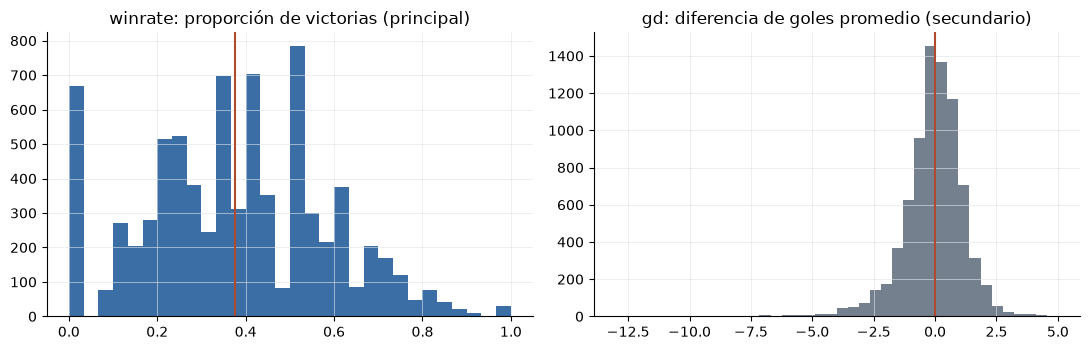


LOS DOS TARGETS
--------------------------------------------------------------------
        winrate        gd
count  7792.000  7792.000
mean      0.370    -0.057
std       0.207     1.231
min       0.000   -13.000
25%       0.222    -0.643
50%       0.375     0.000
75%       0.500     0.667
max       1.000     5.000

FORMA DE LA DISTRIBUCIÓN
--------------------------------------------------------------------
  sesgo de winrate                      0.135
  sesgo de gd                          -1.239
  años sin ganar un solo partido          669  (8.6%)
  años ganando todos los partidos          29  (0.4%)


In [132]:
plt.figure(figsize=(11, 3.6))

plt.subplot(1, 2, 1)
plt.hist(modelo_df["winrate"], bins=30, color=AZUL)
plt.axvline(modelo_df["winrate"].median(), color=ROJO)
plt.title("winrate: proporción de victorias (principal)")
eje_limpio(plt.gca())

plt.subplot(1, 2, 2)
plt.hist(modelo_df["gd"], bins=40, color=GRIS)
plt.axvline(modelo_df["gd"].median(), color=ROJO)
plt.title("gd: diferencia de goles promedio (secundario)")
eje_limpio(plt.gca())

plt.tight_layout()
plt.show()

titulo("LOS DOS TARGETS")
print(modelo_df[["winrate", "gd"]].describe().round(3).to_string())

titulo("FORMA DE LA DISTRIBUCIÓN")
print(f"  {'sesgo de winrate':<34} {modelo_df['winrate'].skew():>8.3f}")
print(f"  {'sesgo de gd':<34} {modelo_df['gd'].skew():>8.3f}")
print(f"  {'años sin ganar un solo partido':<34} {(modelo_df['winrate'] == 0).sum():>8,}"
      f"  ({(modelo_df['winrate'] == 0).mean():.1%})")
print(f"  {'años ganando todos los partidos':<34} {(modelo_df['winrate'] == 1).sum():>8,}"
      f"  ({(modelo_df['winrate'] == 1).mean():.1%})")


**Conclusión.** Las dos distribuciones no se parecen, y la diferencia justifica por sí sola cuál se eligió como target principal.

`winrate` es casi simétrica (sesgo 0.135), centrada en 0.370 de media y 0.375 de mediana. Que el centro no esté en 0.5 tiene una explicación clara, los empates. Cada partido reparte como máximo una victoria entre dos equipos, y el 26% de los partidos terminan en empate, así que el promedio esperado es cercano a (1 − 0.26) / 2 ≈ 0.37. 

`gd` está fuertemente sesgada a la izquierda (sesgo −1.239) y su rango es asimétrico: va de −13.0 a +5.0. Es decir, hay selecciones que en un año promediaron trece goles de desventaja por partido, pero ninguna promedió más de cinco a favor. Las goleadas recibidas castigan mucho más de lo que premian las infligidas y una sola humillación arrastra el promedio anual de un país entero.

Esa asimetría es exactamente el argumento para usar `winrate` como target principal: un 0-13 y un 0-1 son la misma derrota en la tabla de clasificación, pero en `gd` pesan trece veces distinto.


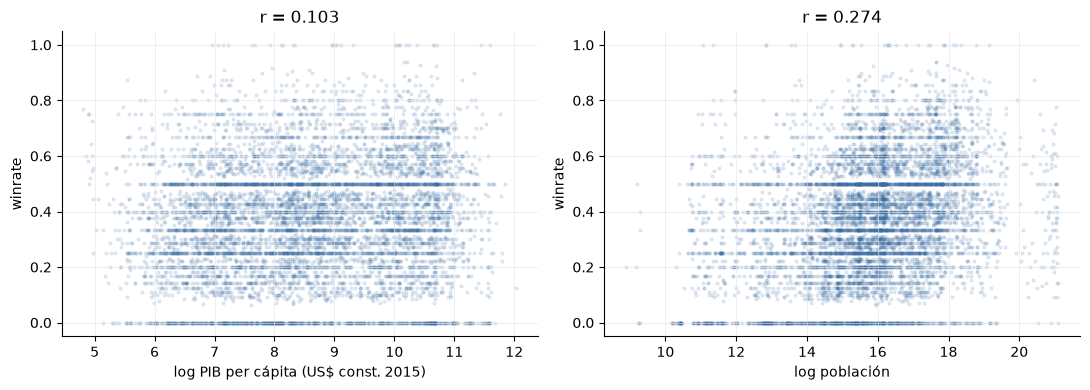


CORRELACIÓN DE CADA PREDICTOR CON LOS DOS TARGETS
--------------------------------------------------------------------
                   winrate        gd
  log_gdppc          0.103     0.074
  log_pop            0.274     0.323
  pct_local          0.140     0.170
  pct_oficial       -0.043    -0.115
  n_partidos         0.236     0.257

  La población pesa 2.7x más que el PIB sobre winrate,
  y 4.3x más sobre gd.


In [133]:
# la pregunta central: el dinero compra victorias?
plt.figure(figsize=(11, 4))

for pos, (col, etiqueta) in enumerate([("log_gdppc", "log PIB per cápita (US$ const. 2015)"),
                                       ("log_pop", "log población")], start=1):
    plt.subplot(1, 2, pos)
    plt.scatter(modelo_df[col], modelo_df["winrate"], s=4, alpha=0.12, color=AZUL)
    r = modelo_df[col].corr(modelo_df["winrate"])
    plt.xlabel(etiqueta)
    plt.ylabel("winrate")
    plt.title(f"r = {r:.3f}")
    eje_limpio(plt.gca())

plt.tight_layout()
plt.show()

corrs = modelo_df[["log_gdppc", "log_pop", "pct_local", "pct_oficial", "n_partidos",
                   "winrate", "gd"]].corr()[["winrate", "gd"]]

titulo("CORRELACIÓN DE CADA PREDICTOR CON LOS DOS TARGETS")
print(f"  {'':<14} {'winrate':>9} {'gd':>9}")
for nombre in ["log_gdppc", "log_pop", "pct_local", "pct_oficial", "n_partidos"]:
    print(f"  {nombre:<14} {corrs.loc[nombre, 'winrate']:>9.3f} {corrs.loc[nombre, 'gd']:>9.3f}")
print()
print(f"  La población pesa {corrs.loc['log_pop', 'winrate'] / corrs.loc['log_gdppc', 'winrate']:.1f}x "
      f"más que el PIB sobre winrate,")
print(f"  y {corrs.loc['log_pop', 'gd'] / corrs.loc['log_gdppc', 'gd']:.1f}x más sobre gd.")


**Conclusión.** La respuesta a la pregunta del proyecto ya se ve en estos dos scatter, y es que **no**: el dinero casi no compra victorias.

La correlación del PIB per cápita con `winrate` es de **0.103**, y la de la población es de **0.274** — es decir, la población pesa **2.7 veces más**. Con el target secundario la brecha se abre todavía más, 0.074 contra 0.323, un factor de **4.4**. Las dos nubes de puntos lo confirman visualmente: la del PIB es prácticamente una mancha sin pendiente, mientras que la de la población tiene una inclinación visible aunque con muchísima dispersión.

Los dos targets cuentan la misma historia y en el mismo orden, que es lo que se buscaba al evaluar ambos, si se contradijeran entonces habría que desconfiar de la agregación. No se contradicen.

Conviene no exagerar el hallazgo. Una correlación de 0.274 sigue siendo débil: la población explica una parte pequeña de la variación, y la enorme dispersión vertical en ambos gráficos dice que hay países pobres que ganan mucho y países ricos que pierden mucho. La conclusión honesta no es "la población determina el fútbol", sino "entre las dos variables económicas obvias, la que importa es cuánta gente hay, no cuánto dinero".


In [134]:
# contraejemplo: los paises mas poblados del mundo no son potencias futbolisticas
mas_poblados = (modelo_df.groupby("team")
                .agg(poblacion=("pop", "mean"), pib=("gdppc", "mean"),
                     winrate=("winrate", "mean"), years=("winrate", "size"))
                .query("years >= 15")
                .sort_values("poblacion", ascending=False))

# cuantos partidos de Mundial jugo cada uno
mundiales = partidos[partidos["tournament"] == "FIFA World Cup"]

def partidos_mundial(equipo):
    return int(((mundiales["home_team"] == equipo) | (mundiales["away_team"] == equipo)).sum())

media_global = modelo_df["winrate"].mean()

titulo("LOS 8 PAÍSES MÁS POBLADOS DE LA MUESTRA")
print(f"  {'':<16} {'población':>14} {'winrate':>9} {'part. Mundial':>15}")
for equipo, f in mas_poblados.head(8).iterrows():
    print(f"  {equipo:<16} {f['poblacion']:>14,.0f} {f['winrate']:>9.3f} "
          f"{partidos_mundial(equipo):>15}")

print()
brasil = mas_poblados.loc["Brazil"]
print(f"  Media global de winrate: {media_global:.3f}")
print(f"  Brasil, con {brasil['poblacion'] / mas_poblados.iloc[0]['poblacion']:.0%} "
      f"de la población de China: winrate {brasil['winrate']:.3f} y "
      f"{partidos_mundial('Brazil')} partidos de Mundial.")



LOS 8 PAÍSES MÁS POBLADOS DE LA MUESTRA
--------------------------------------------------------------------
                        población   winrate   part. Mundial
  China             1,181,031,078     0.456               3
  India               954,149,963     0.347               0
  United States       279,525,485     0.438              42
  Indonesia           188,364,306     0.371               1
  Brazil              152,019,454     0.655             119
  Pakistan            149,048,873     0.180               0
  Russia              145,400,395     0.502              45
  Bangladesh          133,455,444     0.248               0

  Media global de winrate: 0.370
  Brasil, con 13% de la población de China: winrate 0.655 y 119 partidos de Mundial.


**Conclusión: la población es una condición necesaria, no suficiente.**

La tabla desarma cualquier lectura ingenua del hallazgo anterior. Los dos países más poblados del planeta son **China** (1,181 millones de habitantes promedio en el período) e **India** (954 millones). China gana el 45.6% de sus partidos y **ha jugado tres partidos de Copa del Mundo en toda su historia**; India gana el 34.7%, por debajo de la media global de 37.0%, y **nunca ha jugado uno**.

El contraste con Brasil es brutal: **con apenas el 13% de la población de China, tiene 119 partidos de Mundial** y un winrate de 0.655, el más alto de la muestra. Y Pakistán, el quinto más poblado, gana el 18% de sus partidos. (En la sección 7, cuando se calculen los residuales del modelo, China e India aparecerán en los puestos 130 y 110 de 180: por debajo de lo esperado, no por encima.)

La explicación es que la población mide **cuánta gente podría jugar fútbol, no cuánta lo juega**. En India el deporte nacional es el críquet; en China el fútbol compite con el baloncesto y el tenis de mesa, y el sistema deportivo estatal históricamente priorizó disciplinas olímpicas individuales, donde el retorno en medallas por atleta es mucho mayor. Tener mil millones de habitantes no sirve de nada si el talento atlético se canaliza hacia otro lado.

Esto le pone un techo honesto a la conclusión del proyecto y explica por qué el modelo se queda en un R² de 0.147: **la variable que mejor funciona sigue siendo un proxy pobre de lo que realmente importa**, que es cuántas personas de ese país juegan fútbol en serio. Ninguna de las dos fuentes lo mide.


### El problema del rival

Antes de seguir hay que resolver algo que contamina cualquier medida de desempeño: **ni `winrate` ni `gd` saben contra quién se jugó.**

Ganar el 80% de los partidos significa cosas distintas si los rivales son Alemania y Francia o si son Tonga y Samoa Americana. Una selección aislada en una confederación débil acumula victorias y goles sin ser buena; una selección europea de nivel medio pierde la mitad de sus partidos siendo mucho mejor que aquella. Esto es un componente grave sesga sistemáticamente el análisis a favor de los países pequeños y aislados, que son justo los que más pesan en la parte baja de la escala económica.

La celda siguiente lo mide.


In [135]:
# fuerza del rival: diferencia de goles historica de cada seleccion
fuerza = largo.groupby("team")["gd"].mean()
largo["fuerza_rival"] = largo["opponent"].map(fuerza)

rivales = (largo[largo["year"] >= 1960]
           .groupby(["team", "year"])["fuerza_rival"]
           .mean()
           .reset_index())

modelo_df = modelo_df.merge(rivales, on=["team", "year"], how="left")

comparacion = (modelo_df.groupby("team")
               .agg(winrate=("winrate", "mean"), gd=("gd", "mean"),
                    rival=("fuerza_rival", "mean"), years=("gd", "size"))
               .query("years >= 20"))

muestra = ["Germany", "Brazil", "Fiji", "Solomon Islands", "Costa Rica", "Guatemala"]

titulo("MISMO DESEMPEÑO APARENTE, RIVALES OPUESTOS")
print(f"  {'':<18} {'winrate':>9} {'gd':>8} {'rival':>9} {'años':>7}")
for equipo in muestra:
    if equipo in comparacion.index:
        f = comparacion.loc[equipo]
        print(f"  {equipo:<18} {f['winrate']:>9.3f} {f['gd']:>8.3f} {f['rival']:>9.3f} {int(f['years']):>7}")



MISMO DESEMPEÑO APARENTE, RIVALES OPUESTOS
--------------------------------------------------------------------
                       winrate       gd     rival    años
  Germany                0.599    1.168     0.237      66
  Brazil                 0.655    1.325     0.267      64
  Fiji                   0.437    0.800    -0.205      34
  Solomon Islands        0.480    0.799    -0.168      23
  Costa Rica             0.402    0.312     0.131      48
  Guatemala              0.351    0.043    -0.029      45


**Conclusión.** La tabla muestra que `winrate` y `gd` miden algo que depende tanto del equipo como de contra quién jugó, y que sin corregirlo el análisis premia a quien tiene rivales fáciles.

El contraste más claro está entre Alemania y Fiyi. Alemania promedia 1.168 goles de diferencia contra rivales cuya fuerza media es **+0.237**; Fiyi promedia 0.800 contra rivales de **−0.205**. La diferencia de goles de Fiyi es dos tercios de la de Alemania, pero la consigue contra selecciones que son, en promedio, **0.44 goles por partido más débiles**. Islas Salomón repite el patrón casi exacto (0.799 de diferencia, rivales en −0.168).

No son casos aislados, son selecciones de la OFC, una confederación donde los rivales disponibles son mucho más débiles que en Europa o Sudamérica. Sin controlar esto, el modelo concluiría que los países pequeños y pobres del Pacífico son potencias futbolísticas.

El caso local también cambia de lectura. Costa Rica tiene mejor `winrate` que Guatemala (0.402 contra 0.351) y además enfrenta rivales más duros (+0.131 contra −0.029). La ventaja de Costa Rica no viene de un calendario más cómodo, esta es real y está subestimada por la comparación directa.

Por eso `fuerza_rival` entra como feature en la siguiente sección. Existe porque golear a Tonga no es lo mismo que empatar con Alemania.


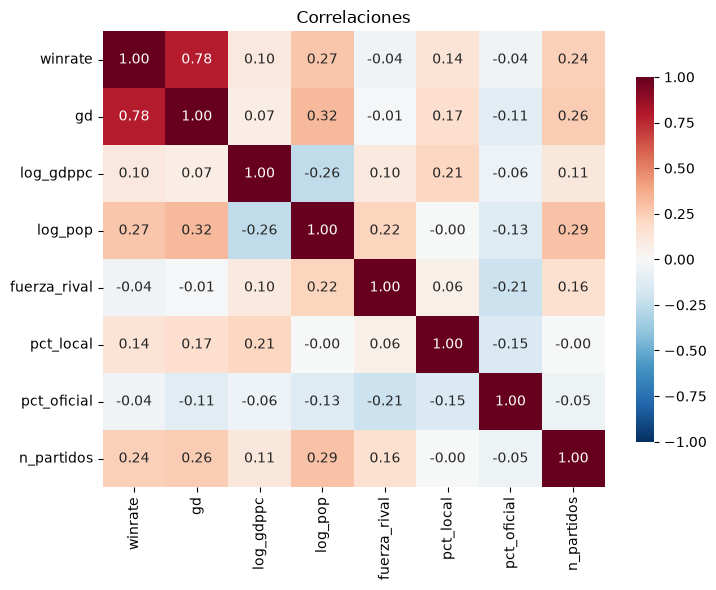

In [136]:
# matriz de correlacion (recordar: correlacion no es causalidad)
cols = ["winrate", "gd", "log_gdppc", "log_pop", "fuerza_rival", "pct_local",
        "pct_oficial", "n_partidos"]

plt.figure(figsize=(7.5, 6))
sns.heatmap(modelo_df[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
plt.title("Correlaciones")
plt.tight_layout()
plt.show()


**Conclusión.** El mapa de calor deja tres cosas a la vista.

La primera es que **el PIB per cápita y la población están correlacionados negativamente (−0.257)**: los países ricos tienden a ser más chicos. Eso es útil, porque significa que no son variables redundantes, cada una aporta información propia y también obliga a leer los coeficientes del modelo con cuidado, ya que apuntan en direcciones parcialmente opuestas.

La segunda es que **`n_partidos` correlaciona 0.236 con `winrate`**, y esa correlación es una trampa de causalidad invertida: no es que jugar más partidos haga ganar, es que ganar hace jugar más partidos, porque avanzar de ronda en un torneo agrega fechas al calendario. Por eso `n_partidos` quedó fuera de la lista de features, aunque predeciría bien.

La tercera es que **`fuerza_rival` casi no correlaciona con `winrate` por sí sola (−0.040)**. Eso no la invalida nuestro análisis, no está ahí para predecir sino para **controlar**. Su trabajo es absorber la ventaja de los calendarios fáciles para que el coeficiente del PIB y el de la población se lean limpios.

---

**Hallazgos del EDA (numerados, cada uno con la gráfica que lo respalda):**

1. **El dinero casi no explica el desempeño futbolístico; la población sí, aunque poco.** El PIB per cápita correlaciona 0.103 con la proporción de victorias, contra 0.274 de la población: un factor de 2.7 a favor de la demografía. Con diferencia de goles la brecha llega a 4.4. *(Scatter de la sección 5.2.)*

2. **La diferencia de goles es una medida asimétrica y por eso engañosa.** Su rango va de −13.0 a +5.0 y su sesgo es de −1.239: se puede perder por trece goles de promedio anual, pero nadie gana por más de cinco. Un 0-13 y un 0-1 son la misma derrota en la tabla, pero en `gd` pesan trece veces distinto. Esto es lo que justifica usar `winrate` como target principal. *(Histogramas de la sección 5.1.)*

3. **Ni el `winrate` ni la diferencia de goles saben contra quién se jugó, y eso favorece sistemáticamente a las confederaciones débiles.** Fiyi consigue dos tercios de la diferencia de goles de Alemania contra rivales 0.44 goles por partido más flojos. *(Tabla de la sección 5.3.)*

4. **El PIB y la población se mueven en direcciones opuestas (−0.257).** Los países ricos tienden a ser más chicos, así que las dos variables no son intercambiables ni redundantes: si solo se mirara una, se estaría atribuyendo a la riqueza un efecto que en parte es de tamaño, o al revés. *(Mapa de calor de la sección 5.4.)*


## 6. Feature engineering

**Atención al leakage:** la partición va **antes** de ajustar cualquier transformación.

### Por qué la partición es por país y no aleatoria

Un `train_test_split` normal sobre país-años haría trampa, y de una forma que no salta a la vista. Si "Brasil 2010" cae en train y "Brasil 2011" en test, el modelo no aprende *"la economía predice el fútbol"*: aprende **"Brasil es bueno"**, y después lo verifica en una fila donde Brasil efectivamente sigue siendo bueno. El R² sale inflado y la conclusión es falsa.

Esto es leakage en el sentido exacto de la sesión 10, entrenar con información que no estará disponible al momento de predecir, porque la pregunta real es *"dado un país del que no sé nada más que su economía y su población, ¿qué tan bien juega?"*. Para responder eso, el modelo tiene que generalizar a **países que nunca vio**, no a años nuevos de países conocidos.

La partición correcta separa la **lista de países**, unos van completos a train, otros completos a test.


In [137]:
from sklearn.model_selection import train_test_split

TARGET = "winrate"      # principal
TARGET_ALT = "gd"       # secundario, para contraste

NUMERICAS = ["log_gdppc", "log_pop", "fuerza_rival", "pct_local", "pct_oficial"]
CATEGORICAS = ["region"]

# particion POR PAIS, no por fila.
# .tolist() porque en pandas 3.0 .unique() devuelve un ArrowStringArray
# y train_test_split no lo sabe indexar.
paises = sorted(modelo_df["team"].unique().tolist())
paises_train, paises_test = train_test_split(paises, test_size=0.2, random_state=RANDOM_STATE)

train = modelo_df[modelo_df["team"].isin(paises_train)]
test = modelo_df[modelo_df["team"].isin(paises_test)]

X_train, y_train = train[NUMERICAS + CATEGORICAS], train[TARGET]
X_test, y_test = test[NUMERICAS + CATEGORICAS], test[TARGET]

titulo("PARTICIÓN POR PAÍS")
print(f"  {'':<8} {'filas':>8} {'países':>9}")
print(f"  {'train':<8} {len(train):>8,} {len(paises_train):>9}")
print(f"  {'test':<8} {len(test):>8,} {len(paises_test):>9}")
print()
print(f"  ¿Guatemala está en test? {'sí' if 'Guatemala' in paises_test else 'no'}")

# Verificacion: ningun pais puede estar de los dos lados
assert not (set(paises_train) & set(paises_test))



PARTICIÓN POR PAÍS
--------------------------------------------------------------------
              filas    países
  train       6,147       164
  test        1,645        42

  ¿Guatemala está en test? no


**Una sutileza sobre `fuerza_rival`.** Arriba se calculó con todos los partidos de la historia, incluidos los de los países que quedaron en test. Estrictamente, eso es una fuga pequeña, el valor del feature para un país de train se construyó en parte con resultados de países de test.

**Por qué se deja así.** La alternativa limpia sería recalcular la fuerza de cada rival usando solo partidos entre países de train, y el remedio sale peor que la enfermedad: los rivales que no cayeron en train se quedarían sin valor de fuerza y habría que imputarlos, justamente en las selecciones aisladas que este feature existe para corregir. Además, lo que se filtra no es el target: `fuerza_rival` es un promedio histórico de diferencia de goles agregado sobre decenas de miles de partidos, donde ningún país-año individual pesa de forma apreciable, y no toca el `winrate` de la fila que se está prediciendo. La fuga existe, es de segundo orden, y queda declarada aquí en lugar de barrida debajo de la alfombra.

**Qué haría falta para eliminarla del todo.** Un rating tipo Elo, actualizado partido a partido en orden cronológico y usando solo el pasado de cada encuentro. Resolvería a la vez esta fuga y el límite 5 de la sección 8. Queda anotado como lo que haría en una segunda versión, no como algo que este proyecto ya resolvió.

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

preproceso = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("esc", StandardScaler())]), NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAS),
])

# el fit pasa solo dentro del Pipeline, con train. Nunca sobre modelo_df completo.


**Features y su justificación:**

| Feature | Cómo se construyó | Por qué debería ayudar |
|---|---|---|
| `log_gdppc` | log del PIB per cápita en US$ constantes de 2015 | Es la variable de la pregunta. En log porque la riqueza es multiplicativa: la diferencia entre \$1k y \$2k importa más que entre \$40k y \$41k |
| `log_pop` | log de la población total | Más gente es más jugadores entre los que elegir. En log por la misma razón |
| `fuerza_rival` | diferencia de goles histórica promedio de los rivales que enfrentó ese año | **Existe porque golear a Tonga no es lo mismo que empatar con Alemania.** Sin este control, las selecciones aisladas en confederaciones débiles se ven artificialmente buenas |
| `pct_local` | proporción de partidos jugados en casa (excluyendo cancha neutral) | La ventaja de local está documentada en todos los deportes; sin controlarla, un año con muchos partidos en casa infla el desempeño |
| `pct_oficial` | proporción de partidos que no son amistosos | Los amistosos se juegan con suplentes y a veces contra rivales de conveniencia: no miden lo mismo |
| `region` | región del Banco Mundial (one-hot) | Captura el nivel competitivo de la confederación y factores culturales que el PIB no ve. One-hot y no ordinal porque entre regiones no hay orden |

**Lo que deliberadamente NO se incluye:**

- **El nombre del país.** Sería memorizar en lugar de explicar, y haría imposible responder la pregunta para un país nuevo.
- **El desempeño de años anteriores.** Predeciría muy bien y no diría nada: el fútbol de ayer explica el de hoy sin necesidad de economía. La pregunta es qué explica la economía, no qué explica la inercia.
- **`n_partidos`.** Es consecuencia del calendario y del éxito (avanzar de ronda da más partidos), no una causa del desempeño.


## 7. Modelo baseline

Primero el trivial, después el propuesto. Sin el trivial, un número no significa nada.


In [139]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    fila = {"modelo": nombre}
    for etiqueta, X, y in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
        pred = modelo.predict(X)
        fila["RMSE_" + etiqueta] = np.sqrt(mean_squared_error(y, pred))
        fila["MAE_" + etiqueta] = mean_absolute_error(y, pred)
        fila["R2_" + etiqueta] = r2_score(y, pred)
    return fila


# imprime la tabla de resultados alineada, con la mejora sobre el trivial
def mostrar(resultados, target):
    titulo(f"RESULTADOS — target: {target}")
    print(f"  {'modelo':<20} {'MAE train':>10} {'MAE test':>10} {'RMSE test':>11} {'R2 test':>9}")
    for _, f in resultados.iterrows():
        print(f"  {f['modelo']:<20} {f['MAE_train']:>10.4f} {f['MAE_test']:>10.4f} "
              f"{f['RMSE_test']:>11.4f} {f['R2_test']:>9.4f}")
    mejora = 1 - resultados["MAE_test"].iloc[1] / resultados["MAE_test"].iloc[0]
    print()
    print(f"  El modelo le gana al trivial por {mejora:.1%} de MAE en test.")


# baseline trivial: predecir siempre la media del train
trivial = Pipeline([("pre", preproceso), ("m", DummyRegressor(strategy="mean"))])

# modelo propuesto
lineal = Pipeline([("pre", preproceso), ("m", LinearRegression())])

resultados = pd.DataFrame([
    evaluar("Trivial (media)", trivial, X_train, y_train, X_test, y_test),
    evaluar("Regresión lineal", lineal, X_train, y_train, X_test, y_test),
])

mostrar(resultados, TARGET)



RESULTADOS — target: winrate
--------------------------------------------------------------------
  modelo                MAE train   MAE test   RMSE test   R2 test
  Trivial (media)          0.1700     0.1621      0.2015   -0.0019
  Regresión lineal         0.1538     0.1489      0.1859    0.1472

  El modelo le gana al trivial por 8.1% de MAE en test.


**Sobre la métrica.** El target es una proporción entre 0 y 1, así que el **MAE se lee directo**: un MAE de 0.12 significa que le erramos, en promedio, 12 puntos porcentuales de victorias. Se reporta RMSE porque penaliza más los errores grandes, y R² para ver qué fracción de la varianza se explica, pero el número que hay que mirar contra el trivial es el MAE, porque es el que se puede interpretar sin traducir.


In [140]:
# contraste: el target secundario cuenta la misma historia?
y_train_alt, y_test_alt = train[TARGET_ALT], test[TARGET_ALT]

resultados_alt = pd.DataFrame([
    evaluar("Trivial (media)", trivial, X_train, y_train_alt, X_test, y_test_alt),
    evaluar("Regresión lineal", lineal, X_train, y_train_alt, X_test, y_test_alt),
])

mostrar(resultados_alt, TARGET_ALT)



RESULTADOS — target: gd
--------------------------------------------------------------------
  modelo                MAE train   MAE test   RMSE test   R2 test
  Trivial (media)          0.9028     0.7946      1.0725   -0.0003
  Regresión lineal         0.7971     0.7359      0.9910    0.1460

  El modelo le gana al trivial por 7.4% de MAE en test.


In [141]:
# que peso le da el modelo a cada variable
lineal.fit(X_train, y_train)

nombres = lineal.named_steps["pre"].get_feature_names_out()
pesos = pd.Series(lineal.named_steps["m"].coef_, index=nombres).sort_values(key=abs, ascending=False)

titulo("COEFICIENTES (features estandarizadas, comparables entre sí)")
for nombre, valor in pesos.items():
    etiqueta = nombre.replace("num__", "").replace("cat__region_", "region: ")
    barra = "#" * int(abs(valor) * 100)
    print(f"  {etiqueta:<42} {valor:>8.4f}  {barra}")



COEFICIENTES (features estandarizadas, comparables entre sí)
--------------------------------------------------------------------
  region: South Asia                          -0.1273  ############
  log_pop                                      0.0891  ########
  region: Latin America & Caribbean            0.0737  #######
  region: Sub-Saharan Africa                   0.0690  ######
  region: Middle East, North Africa, Afghanistan & Pakistan   0.0503  #####
  log_gdppc                                    0.0479  ####
  fuerza_rival                                -0.0378  ###
  region: Europe & Central Asia                0.0255  ##
  pct_local                                    0.0209  ##
  pct_oficial                                  0.0038  
  region: North America                        0.0026  


**Resultados:**

Target principal — `winrate` (proporción de victorias):

| Modelo | MAE train | MAE test | RMSE test | R² test |
|---|---|---|---|---|
| Trivial (media) | 0.1700 | 0.1621 | 0.2015 | **−0.0019** |
| Regresión lineal | 0.1538 | **0.1489** | 0.1859 | **0.1472** |

Target secundario — `gd` (diferencia de goles):

| Modelo | MAE train | MAE test | RMSE test | R² test |
|---|---|---|---|---|
| Trivial (media) | 0.9028 | 0.7946 | 1.0725 | −0.0003 |
| Regresión lineal | 0.7971 | **0.7359** | 0.9910 | 0.1460 |

**¿Le gana el modelo propuesto al trivial?** Sí, pero por poco. El MAE en test baja de 0.1621 a 0.1489: una mejora de **8.1%**, o de 1.3 puntos porcentuales de victorias. En términos concretos, el baseline trivial le erra por 16.2 puntos porcentuales y el modelo por 14.9. El R² de 0.147 dice que la economía y la demografía juntas explican cerca del **15% de la variación** del desempeño futbolístico.

**¿Los dos targets dan la misma conclusión?** Sí. Con `gd` la mejora del MAE es de 7.4% y el R² de test es 0.1460, prácticamente idéntico al 0.1472 de `winrate`. Que dos targets construidos de forma distinta lleguen al mismo número refuerza que el resultado no es un artefacto de cómo se definió la variable objetivo.

**¿Qué coeficiente pesa más?** El de la población, **casi el doble** que el del PIB: 0.0891 contra 0.0479 sobre features estandarizadas (comparables entre sí). Es la misma conclusión del EDA, ahora controlando por región, calendario y fuerza del rival. `fuerza_rival` entra con signo negativo (−0.0378), que es exactamente lo que debía pasar: enfrentar rivales más fuertes baja la proporción de victorias. El control funciona.

**¿Vale la pena la complejidad extra?** Mas o menos. Un R² de 0.147 no sirve para pronosticar el rendimiento de una selección. Pero el proyecto no buscaba predecir, buscaba **medir**. Un modelo que explica solo el 15% es en sí mismo la respuesta a la pregunta, el fútbol no lo determina la economía, y además es la herramienta que permite calcular el residual de Guatemala, que es lo que sigue.

**Una advertencia sobre el R² negativo del trivial.** El −0.0019 en test no es un error: el baseline predice la media del **train**, y como la partición es por país, la media del test es ligeramente distinta. Un R² apenas bajo cero es el comportamiento correcto de un modelo que no aprendió nada.


In [142]:
# Guatemala: el residual, que es el punto de todo esto
modelo_completo = Pipeline([("pre", preproceso), ("m", LinearRegression())])
modelo_completo.fit(X_train, y_train)

todos = modelo_df.copy()
todos["pred"] = modelo_completo.predict(todos[NUMERICAS + CATEGORICAS])
todos["residual"] = todos[TARGET] - todos["pred"]

res_pais = (todos.groupby("team")
            .agg(observado=(TARGET, "mean"), esperado=("pred", "mean"),
                 residual=("residual", "mean"), years=("residual", "size"))
            .query("years >= 15")
            .sort_values("residual", ascending=False))

CONCACAF = ["Guatemala", "Costa Rica", "Honduras", "El Salvador", "Panama",
            "Nicaragua", "Belize", "Mexico", "United States", "Jamaica",
            "Trinidad and Tobago", "Canada", "Haiti", "Cuba"]

titulo("CONCACAF: QUIÉN RINDE POR ENCIMA DE LO QUE SU ECONOMÍA PREDICE")
print(f"  {'':<22} {'observado':>10} {'esperado':>10} {'residual':>10} {'años':>7}")
for equipo, f in res_pais.loc[res_pais.index.intersection(CONCACAF)].iterrows():
    marca = "  <--" if equipo == "Guatemala" else ""
    print(f"  {equipo:<22} {f['observado']:>10.3f} {f['esperado']:>10.3f} "
          f"{f['residual']:>+10.3f} {int(f['years']):>7}{marca}")

gt_res = res_pais.loc["Guatemala"]
percentil = (res_pais["residual"] < gt_res["residual"]).mean()

titulo("GUATEMALA")
print(f"  residual {gt_res['residual']:+.3f}  ->  percentil {percentil:.0%} de {len(res_pais)} países")

titulo("CONTEXTO CENTROAMERICANO")
print(f"  {'':<16} {'PIB per cápita':>16} {'población':>14} {'residual':>10}")
for p in ["Guatemala", "Costa Rica", "Honduras", "El Salvador"]:
    s = todos[todos["team"] == p]
    print(f"  {p:<16} {s['gdppc'].mean():>15,.0f}$ {s['pop'].mean():>14,.0f} "
          f"{res_pais.loc[p, 'residual']:>+10.3f}")



CONCACAF: QUIÉN RINDE POR ENCIMA DE LO QUE SU ECONOMÍA PREDICE
--------------------------------------------------------------------
                          observado   esperado   residual    años
  Haiti                       0.433      0.359     +0.074      48
  Trinidad and Tobago         0.394      0.333     +0.061      60
  Honduras                    0.383      0.325     +0.057      47
  Costa Rica                  0.402      0.362     +0.040      48
  Jamaica                     0.372      0.343     +0.028      43
  Mexico                      0.511      0.492     +0.019      59
  Cuba                        0.371      0.410     -0.038      36
  Panama                      0.333      0.371     -0.039      37
  Guatemala                   0.351      0.395     -0.044      45  <--
  El Salvador                 0.309      0.353     -0.044      48
  Canada                      0.369      0.439     -0.070      46
  Nicaragua                   0.289      0.368     -0.079      19
  Un

**Conclusión sobre Guatemala.** El residual es **negativo: −0.044**, que la deja en el **percentil 34** de 180 países. Guatemala gana el 35.1% de sus partidos cuando su economía y su población predicen 39.5%. No es un desplome, pero tampoco es ruido: son 4.4 puntos porcentuales de victorias por debajo de lo esperado, sostenidos a lo largo de 45 años.

Lo revelador es la comparación regional, y hay un dato que la vuelve incómoda:

| | PIB per cápita | Población | Observado | Esperado | Residual |
|---|---|---|---|---|---|
| Costa Rica | $8,559 | 3.7 M | 0.402 | 0.362 | **+0.040** |
| Honduras | **$1,443** | 6.7 M | 0.383 | 0.325 | **+0.057** |
| **Guatemala** | **$3,256** | **11.4 M** | **0.351** | **0.395** | **−0.044** |
| El Salvador | $3,193 | 5.5 M | 0.309 | 0.353 | −0.044 |

**Honduras es menos de la mitad de rico que Guatemala** —$1,443 contra $3,256 de PIB per cápita promedio— tiene **4.8 millones de habitantes menos**, y aun así gana más partidos en términos absolutos (0.383 contra 0.351) y rinde **por encima** de su expectativa mientras Guatemala rinde por debajo. Costa Rica, con un tercio de la población, hace lo mismo.

Es decir: Guatemala tiene la población más grande de Centroamérica y un ingreso intermedio, que son justamente las dos condiciones que el modelo asocia con ganar. El modelo la coloca como la selección con **la expectativa más alta de las cuatro** (0.395, por encima de Costa Rica). Y es la única de las cuatro que queda por debajo junto con El Salvador.

La brecha entre el −0.044 de Guatemala y el +0.057 de Honduras no la explica la economía, porque si la economía mandara, la comparación iría al revés. Sea lo que sea que Honduras y Costa Rica hacen mejor —formación, liga, continuidad técnica, organización federativa—, no está en estos datos. Respondiendo a la pregunta original: **si el techo de Guatemala lo pusiera el PIB, no habría nada que hacer; el hecho de que Honduras lo supere siendo más pobre significa que el margen existe.**

*Nota metodológica: Guatemala no está en el conjunto de test, así que su residual se calcula con un modelo que la vio en entrenamiento.*


## 8. Conclusiones y límites

### Respuesta a la pregunta

*¿El dinero compra goles? ¿Qué pesa más? ¿Y dónde cae Guatemala?*

| Dato | Valor |
|---|---|
| Correlación PIB – winrate | +0.103 |
| Correlación población – winrate | +0.274 |
| Coeficiente `log_pop` vs `log_gdppc` | 0.0891 vs 0.0479 → **1.86×** |
| R² en test (winrate / gd) | 0.1472 / 0.1460 → queda **sin explicar ~85%** |
| MAE en test: trivial → modelo | 0.1621 → 0.1489 (mejora 8.1%) |

### Guatemala en su región

| | PIB per cápita | Población | Observado | Esperado | Residual |
|---|---|---|---|---|---|
| Honduras | $1,443 | 6,654,556 | 0.383 | 0.325 | **+0.057** |
| Costa Rica | $8,559 | 3,695,978 | 0.402 | 0.362 | **+0.040** |
| Panamá | $9,882 | 3,281,487 | 0.333 | 0.371 | −0.039 |
| **Guatemala** | **$3,256** | **11,445,037** | **0.351** | **0.395** | **−0.044** |
| El Salvador | $3,193 | 5,453,846 | 0.309 | 0.353 | −0.044 |
| Estados Unidos | $46,540 | 279,525,485 | 0.438 | 0.563 | −0.125 |

Guatemala queda en el **percentil 34 de 180 países**.

Guatemala tiene la población más grande de Centroamérica, y por eso el modelo le asigna la expectativa más alta de las cuatro (0.395). Honduras tiene menos de la mitad de su PIB per cápita y aun así gana más partidos en términos absolutos. Si la economía mandara, esa comparación iría al revés.

*Si el techo de Guatemala lo pusiera el PIB, no habría nada que hacer; el hecho de que Honduras lo supere siendo más pobre significa que el margen existe.*

### Límites

| # | Límite | Dato de respaldo |
|---|---|---|
| 1 | Correlación no es causalidad | El enunciado lo penaliza explícitamente |
| 2 | Muestra sesgada hacia países grandes | Los países sin PIB tienen hasta **36× menos población** (1990) |
| 3 | Estados desaparecidos excluidos | **111 país-años**: Checoslovaquia 34, Yugoslavia 32, RDA 29, Vietnam Rep. 16 |
| 4 | Reino Unido con PIB aproximado | **261 país-años** marcados con `gdppc_aproximado` |
| 5 | `fuerza_rival` se queda corta | Los que más sobre-rinden siguen siendo OFC: Islas Salomón +0.306, Fiyi +0.211, Vanuatu +0.197 |
| 6 | El target no distingue el tipo de partido | **37%** de los partidos son amistosos; `pct_oficial` solo controla en parte |
| 7 | La población es un proxy pobre | China −0.061 e India −0.029: puestos **130 y 110 de 180** |
| 8 | El modelo no distingue "juega mal" de "le importa otro deporte" | EE.UU. residual **−0.125**, el peor de CONCACAF |
| 9 | El PIB per cápita no es el presupuesto del fútbol | Es el proxy disponible, no la variable que se querría |

*Retención final del pipeline: 86.4% — 7,792 filas, 206 países, 1960–2025.*

### Qué haría falta para responderla mejor

- Una medida de **esfuerzo deportivo** y no de riqueza general (presupuesto federativo, jugadores federados, clubes profesionales) → separaría *no tiene recursos* de *no los usa en fútbol*, que es la distinción que el límite 7 y el 9 dejan abierta.
- Un **rating tipo Elo** en vez de `winrate` → resolvería de raíz el límite 5, porque ajusta por la fuerza del rival partido a partido en lugar de con un promedio histórico plano.
- Datos de la **liga doméstica** (equipos, asistencia, jugadores que emigran) → permitiría probar si la brecha Guatemala–Honduras se explica por lo que pasa dentro de cada país.


## 9. Bitácora de colaboración con AI

Según la política del curso, se documenta el uso de asistencia de AI en este proyecto.

**Herramienta:** Claude (Anthropic), usado desde Claude Code en la terminal.

### Qué decidí y aporté yo

| Aporte | En qué consistió |
|---|---|
| **Dominio y ángulo del proyecto** | Definí los temas a investigar basándome en mis gustos personales. Elegí el cruce fútbol–economía con Guatemala como caso para explorar el fracaso deportivo de la no-clasificación al Mundial 2026 |
| **Diseño de la variable objetivo** | Decidí usar **dos** targets en lugar de uno, y que `winrate` fuera el principal y `gd` el de contraste. Esa estructura del análisis es mía |
| **El control por fuerza del rival** | Decidí darle peso propio dentro del EDA, porque comparar desempeños sin mirar contra quién se jugó invalidaba la conclusión |
| **Enriquecimiento de la data faltante** | Investigué si los datos del Reino Unido y los de los estados desaparecidos se podían traer de otra fuente. Esa pregunta llevó a evaluar el Maddison Project, y de ahí salió el error del indicador en dólares corrientes |
| **El contraejemplo China / India** | Identifiqué que los dos países más poblados del mundo no son potencias futbolísticas y decidí incorporarlo. Es lo que le pone el techo honesto al hallazgo sobre la población |
| **Código** | Escribí las funciones de carga, la agregación a país-año, el diccionario de nombres, el merge y el pipeline de modelado, armándolos sección por sección sobre la estructura de mis hojas de trabajo anteriores y usando el autocomplete para adaptar la mayor parte. Definí el estilo y verifiqué que los números se reprodujeran |
| **Redacción** | Redacté las conclusiones de las secciones 5 y 7 a partir de las salidas reales. Analicé los resultados obtenidos para encontrar las respuestas a mis planteamientos iniciales y observé cómo la falta de variables no permitía un `R²` alto |

### En qué ayudó la AI

| Etapa | Qué hizo | Qué decidí yo |
|---|---|---|
| Búsqueda de datasets | Propuso opciones para los temas que le di y verificó disponibilidad, licencia y tamaño de cada una antes de recomendar | Elegí los que se adaptaban a mi tema y descarté el resto |
| Validación previa | Bajó las fuentes y midió el merge real (77.4% → 90.4% con diccionario) antes de comprometer el proyecto | Confirmé que la muestra alcanzaba |
| Evaluación de fuentes extra | Comparó ONS y Maddison Project contra el Banco Mundial con criterios medidos | Acepté incluir ONS y excluir los estados desaparecidos |
| Corrección de un error | Al comparar Maddison con el Banco Mundial detectó que `NY.GDP.PCAP.CD` (dólares corrientes) mezclaba inflación con crecimiento real | Cambié a `NY.GDP.PCAP.KD`, en dólares constantes |
| Estructura y formato | Armó el esqueleto de secciones del notebook y el formato markdown (tablas, encabezados, tablas de resultados, estilizado) | Reescribí el contenido de las secciones 1 a 7 sobre esa estructura |
| Revisión y estilo del código | Revisó el código por bugs, arregló sintaxis en algunas partes y optimizó ciertas funciones | Definí que el código siguiera las convenciones de mis hojas de trabajo y pedí reordenar la impresión de resultados |

### Qué verifiqué yo

- [x] Que el notebook corre completo con **Restart & Run All** y que las cifras citadas en los textos coinciden con la salida de su celda.
- [x] Que **ningún país queda en train y test a la vez** — el `assert` de la celda de partición lo comprueba y pasa.
- [x] Que el diccionario de nombres **no apunta a ningún país inexistente**: las 33 entradas resuelven a un nombre que sí está en el catálogo del Banco Mundial, ninguna queda huérfana.
- [x] Que los **signos de los coeficientes** coinciden con lo que anticipa el EDA: `log_pop` +0.0891 y `log_gdppc` +0.0479, ambos positivos, y `fuerza_rival` −0.0378, negativo como debía ser (rivales más fuertes, menos victorias).

### Qué escribí sin asistencia

Escribí con mis propias palabras los textos de las secciones 1 a 8: la pregunta y el contexto, la descripción de las fuentes, las observaciones del primer barrido, el argumento del mecanismo de los faltantes y la tabla de decisiones, las conclusiones de cada gráfica del EDA y la lectura de los resultados del modelo. También copié la estructura del código de mis anteriores hojas de trabajo, armando sección por sección los pipelines de procesado de datos (usando el autocomplete para adaptar la mayoría del código), y mi agente de Claude Code me revisó por bugs, arregló sintaxis en algunas partes y optimizó ciertas funciones.

## Anexo: peer critique (se llena en clase)

**Revisor:**

1. ¿Entendí la pregunta del proyecto sin preguntarle al autor?
2. ¿Hay alguna gráfica o celda que yo borraría? ¿Cuál y por qué?
3. ¿Veo algún punto donde se pudo haber colado información del test?
